</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>Práctica 1:
        </h2>
        <h1 style="margin-top: -10px;">
            Análisis, procesamiento y validación
        </h1>
    </div>
    <div style="width: 50%; text-align: right;">
        <div style="display: flex; justify-content: space-between; align-items: flex-start; margin-top: 30px;">
            <div style="width: 20%;"></div>
            <div style="width: 80%; border-left: 2px solid #555555; padding-left: 20px;">
                <div style="margin-bottom: 20px;">
                    <p style="margin: 0; font-size: 1.4em; font-weight: bold;">
                        Minería de Datos, 2025-26
                    </p>
                </div>
                <div style="margin-top: 8px; text-align: right;">
                    <span style="font-size: 1em; color: #D0D0D0;">
                        José Antonio Gámez Martín
                    </span>
                    <a href="mailto:Jose.Gamez@uclm.es" style="text-decoration: none; color: #888888; font-size: 0.8em; padding-left: 15px;">
                        ✉ Jose.Gamez@uclm.es
                    </a>
                </div>
                <div style="margin-top: 8px; text-align: right;">
                    <span style="font-size: 1em; color: #D0D0D0;">
                        Pablo Torrijos Arenas
                    </span>
                    <a href="mailto:Pablo.Torrijos@uclm.es" style="text-decoration: none; color: #888888; font-size: 0.8em; padding-left: 15px;">
                        ✉ Pablo.Torrijos@uclm.es
                    </a>
                </div>
                </div>
            </div>
        </div>
    </div>
</div>

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #B30033; font-size: 1.5em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1.4em; font-weight: bold">
            Estudiantes
        </h3>
    </div>
    <ul style="list-style-type: none; padding-left: 28px; margin: 0;  font-size: 1.1em">
        <li>Alberto Pérez Álvarez</li>
        <li>(Estudiante 2)</li>
    </ul>

</div>

## 1. Introducción

El objetivo de esta práctica es aplicar las técnicas de un flujo de trabajo de **minería de datos** para resolver un problema de **clasificación supervisada**. Se analizará un conjunto de datos sobre el rendimiento y la actividad de estudiantes universitarios para predecir la probabilidad de abandono de sus estudios.

El desarrollo abarcará desde el **análisis exploratorio** de los datos y su **preprocesamiento**, hasta el **entrenamiento** de un modelo y su **validación** robusta. 

El rendimiento de los modelos se evaluará en una competición privada en Kaggle, que abarcará esta Práctica 1 y la Práctica 2 (selección de modelos).

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

## 2. Carga y visualización de los datos

Se proporciona un conjunto de datos sintético que simula el rendimiento académico y la interacción de estudiantes durante su primer año. Los datos contienen una variedad de tipos de variables, valores faltantes y otros artefactos que deberán ser gestionados.

Comenzamos importando las librerías necesarias y cargando los conjuntos de datos de entrenamiento (`train`) y de prueba (`test`) para poder examinarlos:

In [10]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df_train = pd.read_csv('./csv/uclm_student_train.csv')
df_train

,id,nombre,nacimiento,provincia,residencia_id,trabaja,horas_trabajo,bachillerato,nota_acceso,modalidad,creditos_a1,superados_a1,nota_s1,satisfaccion,horas_moodle,posts_foro,uso_biblioteca,eventos,tutorias,comentarios,numero_fav,talla_zapato,color_fav,meses_matriculado,grupo_trabajo,abandono
0,TO-2010-GCA531,Graciano Cano Alsina,1992-05-06,Albacete,E1-P02-H04,0,NaN,Científico,6.08,Tiempo completo,60,60,8.16,4.32,~7.2 horas,2,11,1,4,relacion correcto con compañeros,71,43,Azul oscuro,6,GR10335,1
1,CU-2016-MBP239,María Belén Polo,1998-10-31,Cuenca,E2-P03-H06,0,NaN,CIENCIAS PURAS,8.12,Tiempo completo,60,60,9.09,4.05,~11.8 horas,13,2,2,0,Uso normal de la plataforma Moodle,22,38,Coral claro,6,GR13813,0
2,CR-2010-JS201,Judith Sáenz,1992-03-11,Ciudad Real,NaN,0,NaN,Ciencias Puras,10.59,Tiempo completo,60,54,7.99,3.88,~8.8 horas,6,14,2,3,NaN,69,37,Violeta oscuro,6,GR02505,0
3,TO-2016-CDB602,Casandra de Bautista,1998-11-03,Toledo,E1-P04-H18,0,NaN,Humanidades,7.85,Tiempo completo,60,48,7.27,3.81,~8.7 horas,0,0,2,3,Relacion adecuado con compañeros.,3,34,Rosa profundo,6,GR14887,0
4,AB-2011-CAA364,Carlito Alvarado Anaya,1993-12-22,Albacete,NaN,0,NaN,ECONÓMICO,10.23,Tiempo completo,60,60,8.45,4.08,~9.6 horas,16,6,2,3,ha mejorado notablemente en asignaturas troncales,19,39,Coral claro,5,GR09244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40540,AB-2011-CB913,Cecilia Bosch,1993-04-14,Albacete,NaN,0,NaN,CIENCIAS SOCIALES,8.64,Tiempo completo,60,36,5.52,2.94,~1.1h,8,0,3,0,NaN,23,39,Rojo violeta medio,6,GR15949,1
40541,TO-2011-WRL313,Wilfredo Roda Lerma,1987-11-12,Toledo,NaN,1,NaN,Económico,10.59,Tiempo completo,60,60,9.00,4.05,~11.5 horas,8,2,3,2,NaN,76,40,Amarillo,6,GR11547,0
40542,CR-2017-JA946,Javi Acuña,1999-09-05,Ciudad Real,NaN,0,NaN,TECNOLÓGICO,10.41,Tiempo completo,60,54,NaN,3.52,~5.1 horas,3,8,4,4,Expresa dudas sobre continuar los estudios.,24,40,Gris claro,4,GR00625,1
40543,AB-2010-TRM306,Teresita Rodrigo Morera,1992-06-23,Albacete,NaN,0,NaN,Económico,10.15,Tiempo completo,60,54,7.36,3.70,~8.0 horas,10,3,4,0,NaN,39,38,Azul real,6,GR06859,0


In [11]:
df_test = pd.read_csv('csv/uclm_student_test.csv')
df_test

,id,nombre,nacimiento,provincia,residencia_id,trabaja,horas_trabajo,bachillerato,nota_acceso,modalidad,creditos_a1,superados_a1,nota_s1,satisfaccion,horas_moodle,posts_foro,uso_biblioteca,eventos,tutorias,comentarios,numero_fav,talla_zapato,color_fav,meses_matriculado,grupo_trabajo
0,AB-2019-FEM764,Fabiola Espejo Marín,2002-01-12,Ciudad Real,E1-P01-H01,0,NaN,CCSS,10.17,Tiempo completo,60,48,7.74,3.81,~11.0 horas,16,14,5,5,Expresa dudas sobre su vocacion.,43,40,Violeta sonrojado pálido,6,GR01091
1,TO-2018-ALL744,Arsenio Lucas Llanos,2000-06-13,Toledo,NaN,0,NaN,Letras,9.16,Tiempo completo,60,48,6.99,3.28,~6.8 horas,2,5,5,1,NaN,88,40,Cian,6,GR02931
2,AB-2018-ZSD099,Zaira Salvà Dominguez,2000-09-25,Albacete,NaN,0,NaN,Ciencias Puras,8.91,Tiempo completo,60,60,8.28,4.48,10.0,12,2,6,2,Busca activamente prácticas y oportunidades pr...,96,39,Gris oscuro,3,GR06795
3,CR-2019-TCS733,Tatiana Celia Solano Tejera,2001-06-05,Ciudad Real,NaN,0,NaN,Letras,9.29,Tiempo completo,60,24,3.96,1.86,~0.8 horas,10,6,3,1,NaN,62,38,Blanco lavanda,6,GR06712
4,CR-2018-VBV597,Victoriano Benavente Vilaplana,2000-06-18,Ciudad Real,NaN,0,NaN,Letras,5.00,Tiempo completo,60,0,2.85,1.26,~5.9 horas,17,2,2,0,NaN,98,44,Azul Alicia,2,GR01653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9582,AB-2019-AAM365,Albino Acero Múgica,2002-02-14,Albacete,NaN,0,NaN,Tecnológico Industrial,9.38,Tiempo completo,60,30,4.74,2.20,~4.2 horas,11,1,5,0,NaN,98,41,Marrón siena,6,GR13835
9583,AB-2019-MC507,Marina Calleja,2002-01-07,Albacete,NaN,0,NaN,CCSS,6.41,Tiempo completo,60,60,9.52,4.97,~8.4 horas,3,7,6,2,Asistencia constante a clases.,33,38,Amarillo,6,GR14729
9584,AB-2019-MNC716,Morena Noelia Castell Amor,2001-04-05,Albacete,NaN,0,NaN,Letras,9.60,Tiempo completo,60,24,5.09,2.35,7.8,2,9,2,2,Habla de cambiar de ciudad por motivos persona...,96,35,Azul anciano,6,GR11046
9585,AB-2018-ICH450,Isidora Cabrera Hoyos,2001-02-09,Albacete,NaN,1,NaN,CCSS,9.79,Tiempo completo,60,48,7.05,3.59,11.5,12,1,2,2,NaN,82,37,Blanco,6,GR10480


Las variables disponibles son:
`id`, `nombre`, `nacimiento`, `provincia`, `residencia_id`, `trabaja`, `horas_trabajo`, `bachillerato`, `nota_acceso`, `modalidad`, `creditos_a1`, `superados_a1`, `nota_s1`, `satisfaccion`, `horas_moodle`, `posts_foro`, `uso_biblioteca`, `eventos`, `tutorias`, `comentarios`, `numero_fav`, `talla_zapato`, `color_fav`, `meses_matriculado`, `grupo_trabajo`, `abandono`.

La variable objetivo es `abandono`, que es binaria:
* **1**: El estudiante abandona los estudios.
* **0**: El estudiante continúa.

Se puede observar cómo hay variables categóricas, numéricas, fechas, texto, valores faltantes... Esto requerirá de un análisis exploratorio y un preprocesamiento.

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

## 3. Flujo de Trabajo y Requisitos

El desarrollo de la práctica deberá seguir las siguientes etapas:


### 3.1. Análisis Exploratorio de Datos (EDA)

Se debe realizar un análisis inicial para comprender la naturaleza de los datos. Este análisis debe incluir:
* Distribución de la variable objetivo (`abandono`).
* Análisis de valores faltantes.
* Distribución de las variables numéricas y categóricas, valores únicos, outliers...
* Identificación de valores atípicos.
* Relaciones entre las variables y la variable objetivo.

Las conclusiones de este análisis deben servir para justificar las decisiones tomadas en la siguiente etapa.


### 3.2. Preprocesamiento de Datos

Esta etapa es fundamental para preparar los datos antes de la modelización. Las tareas incluyen la imputación de valores faltantes, la codificación de variables categóricas, la ingeniería de características (ej. creación de nuevas variables a partir de las existentes), el escalado de datos o incluso eliminar variables que nos aporten información

Este proceso debe de ir totalmente ligado al EDA. Las conclusiones que hayamos sacado en el estudio son las que nos deben guiar en este paso. Del mismo modo, al preprocesar los datos y entrenar los modelos podemos sacar nuevas conclusiones que nos permitan entender mejor los datos (como habéis visto en **CRISP-DM**):

<img src="https://upload.wikimedia.org/wikipedia/commons/b/b9/CRISP-DM_Process_Diagram.png" alt="Diagrama de Proceso CRISP-DM" width="550"/>

**Requisito obligatorio**: Todo el proceso de transformación de datos **debe** encapsularse en `Pipelines` de `scikit-learn`. En la práctica, además de mantener una mayor claridad y estructura en el código, esto nos ayudará a evitar fugas de datos.


### 3.3. Modelización y Validación

Se debe entrenar y evaluar correctamente **al menos un algoritmo** (ej. Árboles de Decisión, Naive Bayes, etc.). En esta práctica no es importante usar el mejor modelo posible (eso vendrá en la Práctica 2), sino analizar, preparar y evaluar bien los datos.

**Requisito obligatorio**: La evaluación y comparación de los modelos **debe** realizarse mediante una estrategia de **validación cruzada**. Además, es imporante tener en cuenta distintas **métricas** para evaluar nuestro modelo.


### 3.4. Predicción y Evaluación

El modelo final se puede utilizar para generar predicciones sobre el conjunto `uclm_student_test.csv`. Esto es recomendable, pero no es obligatorio en esta práctica (lo será en la Práctica 2).

El fichero de predicciones deberá seguir el formato especificado en `sample_submission.csv`:

In [12]:
df_kaggle = pd.read_csv('csv/sample_submission.csv')
df_kaggle

,id,abandono
0,AB-2019-FEM764,1
1,TO-2018-ALL744,1
2,AB-2018-ZSD099,0
3,CR-2019-TCS733,0
4,CR-2018-VBV597,0
...,...,...
9582,AB-2019-AAM365,0
9583,AB-2019-MC507,1
9584,AB-2019-MNC716,0
9585,AB-2018-ICH450,0


<div style="border-bottom: 2px solid #555555; margin-bottom: 10px">

## 4. Competición en Kaggle

La evaluación final se realizará mediante una competición privada en Kaggle. El objetivo es maximizar la métrica **F1-Score**, una medida robusta que tiene en cuenta tanto la precisión como la exhaustividad, especialmente útil en casos con clases desbalanceadas.

* **Enlace a la competición**: https://www.kaggle.com/t/16fef7f5d88c4dd399f8bad259c55947

Los equipos con mejor rendimiento en el *private leaderboard* recibirán una bonificación en la nota final:
* **1er puesto**: +0.75 puntos.
* **2º puesto**: +0.5 puntos.
* **3er puesto**: +0.25 puntos.

**Nota**: Las bonificaciones están sujetas a la revisión del código y la metodología. Se podrá requerir una justificación del enfoque para verificar la originalidad y la comprensión del trabajo.

## Importaciones

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

## Análisis de los datos

### Análisis de la variable objetivo


Distribución de la variable 'abandono':
abandono
0    30092
1    10453
Name: count, dtype: int64

Porcentaje:
abandono
0    74.218769
1    25.781231
Name: proportion, dtype: float64


/tmp/ipykernel_44992/476528980.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='abandono', data=df_train, palette='viridis')


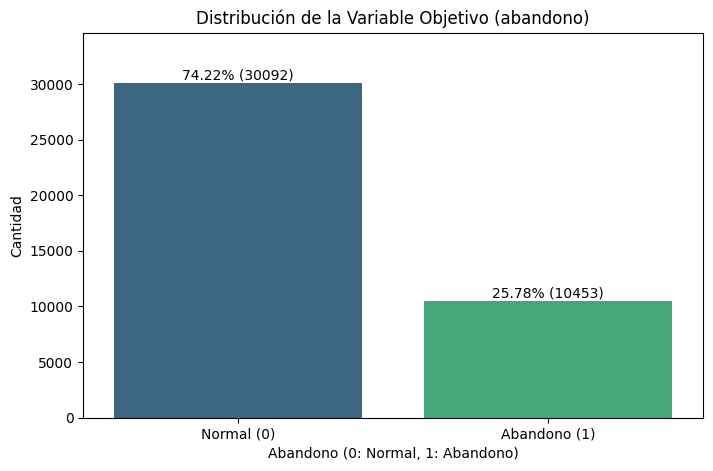

In [14]:
abandono_counts = df_train['abandono'].value_counts()
abandono_perc = df_train['abandono'].value_counts(normalize=True) * 100 # TODO: Mirar si esta normalización produce fuga de datos

print("\nDistribución de la variable 'abandono':")
print(abandono_counts)
print(f"\nPorcentaje:\n{abandono_perc}")

# Visualización
plt.figure(figsize=(8, 5))
sns.countplot(x='abandono', data=df_train, palette='viridis')
plt.title('Distribución de la Variable Objetivo (abandono)')
plt.xlabel('Abandono (0: Normal, 1: Abandono)')
plt.ylabel('Cantidad')
plt.xticks(ticks=[0, 1], labels=['Normal (0)', 'Abandono (1)'])
# Añadir porcentajes en el gráfico
total = len(df_train['abandono'])
for i, count in enumerate(abandono_counts):
    plt.text(i, count + 50, f'{abandono_perc[i]:.2f}% ({count})', ha='center', va='bottom')
plt.ylim(0, max(abandono_counts)*1.15) # Ajustar límite superior para texto
plt.show()

### Análisis de variables numéricas

In [15]:
numerical_cols = []

print("\nEstadísticas descriptivas (df_train):")
print(df_train[numerical_cols].describe())

n_cols = 2
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df_train[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('') 
    axes[i].set_ylabel('Frecuencia')

if len(numerical_cols) < len(axes):
    for j in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Histogramas de Variables Numéricas (Train)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 
plt.show()


fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_train[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('') 


if len(numerical_cols) < len(axes):
    for j in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Boxplots de Variables Numéricas (Train)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


Estadísticas descriptivas (df_train):


ValueError: Cannot describe a DataFrame without columns

### Valores faltantes

In [ ]:
print("\nValores faltantes por columna (df_train):")
missing_train = df_train.isnull().sum()
missing_train_perc = (missing_train / len(df_train)) * 100
missing_train_df = pd.DataFrame({'Count': missing_train, 'Percentage': missing_train_perc})
print(missing_train_df[missing_train_df['Count'] > 0])

# TODO: Analizar el test podría considerarse fuga de datos???

### Análisis de fechas

In [ ]:
original_missing_train = df_train['timestamp'].isnull().sum()

df_train['timestamp'] = pd.to_datetime(df_train['timestamp'], errors='coerce')

df_train['year'] = df_train['timestamp'].dt.year
df_train['month'] = df_train['timestamp'].dt.month
df_train['day'] = df_train['timestamp'].dt.day
print("\nComponentes de fecha/hora extraídos en df_train (year, month, day).")

print(f"\nRango de fechas en df_train: {df_train['timestamp'].min()} a {df_train['timestamp'].max()}")

df_train_sorted = df_train.sort_values('timestamp').copy()
df_train_sorted['YearMonth'] = df_train_sorted['timestamp'].dt.to_period('M')
abandonos_por_mes = df_train_sorted.groupby('YearMonth')['abandono'].sum()

abandonos_por_mes.index = abandonos_por_mes.index.to_timestamp()

plt.figure(figsize=(15, 6))
abandonos_por_mes.plot(kind='line', marker='o', linestyle='-')
plt.title('Número de Abandonos Registrados por Mes')
plt.xlabel('Fecha (Mes)')
plt.ylabel('Número Total de Abandonos')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### Relaciones entre variables

#### Relaciones entre numéricas y objetivo

In [ ]:
# Relaciones entre Numéricas y Objetivo
for i, col in enumerate(numerical_cols):
    sns.boxplot(x='abandono', y=col, data=df_train, ax=axes[i], palette='viridis', showfliers=True) 
    axes[i].set_title(f'{col} vs. Abandono')
    axes[i].set_xlabel('Abandono (0: Normal, 1: Abandono)')
    axes[i].set_ylabel(col)

if len(numerical_cols) < len(axes):
    for j in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Variables Numéricas según la Variable Objetivo (Train)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


#### Relación entre categóricas y objetivo

In [ ]:
# Relaciones entre Categóricas y objetivo
categorical_cols = []

# TODO: Hay que trabajar las categóricas: 
# - No distinguir entre mayus y minus
# - No tener en cuenta los saltos de línea
# - No tener en cuenta las tildes
# - Rellenar los NaN
# - Hay algunas que son texto libre (nombre, id...) y posiblemente podamos ignorarlas

#### Correlación entre variables numéricas

In [ ]:
sns.pairplot(df_train, vars=numerical_cols, hue='abandono', palette='viridis', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot de Variables Numéricas por Abandono', y=1.02)
plt.show()